# Dynamic Programming for Inventory Control

## Bellman Equation

We solve the flower girl problem exactly using **backward induction**. The state is the stock level $x_t$ at the beginning of day $t$.

**Value function:**
$$V_t(x) = \min_{0 \leq u \leq U} \left\{ c \cdot u - p \cdot \mathbb{E}[\min(x + u, d)] + \mathbb{E}[V_{t+1}(\max(x + u - d, 0))] \right\}$$

**Terminal condition:** $V_{T+1}(x) = 0$ (no future value)

**State dynamics:** $x_{t+1} = \max(x_t + u_t - d_t, 0)$

---

## Why DP Works Here
- State space is finite: $x \in \{0, 1, \ldots, D+U\}$
- Action space is finite: $u \in \{0, 1, \ldots, U\}$
- Complexity: $O(T \cdot |X| \cdot |U| \cdot D)$ — polynomial!
- Compare to extensive form: $O(D^T)$ — exponential!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.dynamic_programming import solve_dp, dp_policy_function, print_policy_table
from src.inventory import simulate_policy, anticipative_bound, constant_policy
from src.utils import generate_scenarios, format_result

sns.set_theme(style='whitegrid')

# Parameters
c, p = 1.0, 2.0
D, U, T = 10, 7, 10
print(f"Parameters: c={c}, p={p}, D={D}, U={U}, T={T}")
print(f"State space size: {D + U + 1}")
print(f"DP complexity: O({T} × {D+U+1} × {U+1} × {D}) = O({T*(D+U+1)*(U+1)*D:,})")
print(f"Extensive form scenarios: {D}^{T} = {D**T:,.0f}")

Parameters: c=1.0, p=2.0, D=10, U=7, T=10
State space size: 18
DP complexity: O(10 × 18 × 8 × 10) = O(14,400)
Extensive form scenarios: 10^10 = 10,000,000,000


## 1. Solve by Backward Induction

In [2]:
# Solve DP
V, policy = solve_dp(T, D, c, p, U)

print(f"\n{'='*60}")
print(f"OPTIMAL VALUE (starting with 0 stock): V_0(0) = {V[0, 0]:.4f}")
print(f"{'='*60}")
print(f"\nOptimal Policy Table (u*(t, x)):")
print()
print_policy_table(policy, T, max_display_stock=D)


OPTIMAL VALUE (starting with 0 stock): V_0(0) = -50.9341

Optimal Policy Table (u*(t, x)):

Time  x=0   x=1   x=2   x=3   x=4   x=5   x=6   x=7   x=8   x=9   x=10  
------------------------------------------------------------------------
t=1   7     7     7     7     7     7     7     7     7     7     7     
t=2   7     7     7     7     7     7     7     7     7     7     7     
t=3   7     7     7     7     7     7     7     7     7     7     7     
t=4   7     7     7     7     7     7     7     7     7     7     7     
t=5   7     7     7     7     7     7     7     7     7     7     7     
t=6   7     7     7     7     7     7     7     7     7     7     6     
t=7   7     7     7     7     7     7     7     6     5     4     3     
t=8   7     7     7     7     7     6     5     4     3     2     1     
t=9   7     7     7     6     5     4     3     2     1     0     0     
t=10  6     5     3     3     1     0     0     0     0     0     0     


## 2. Value Function Visualization

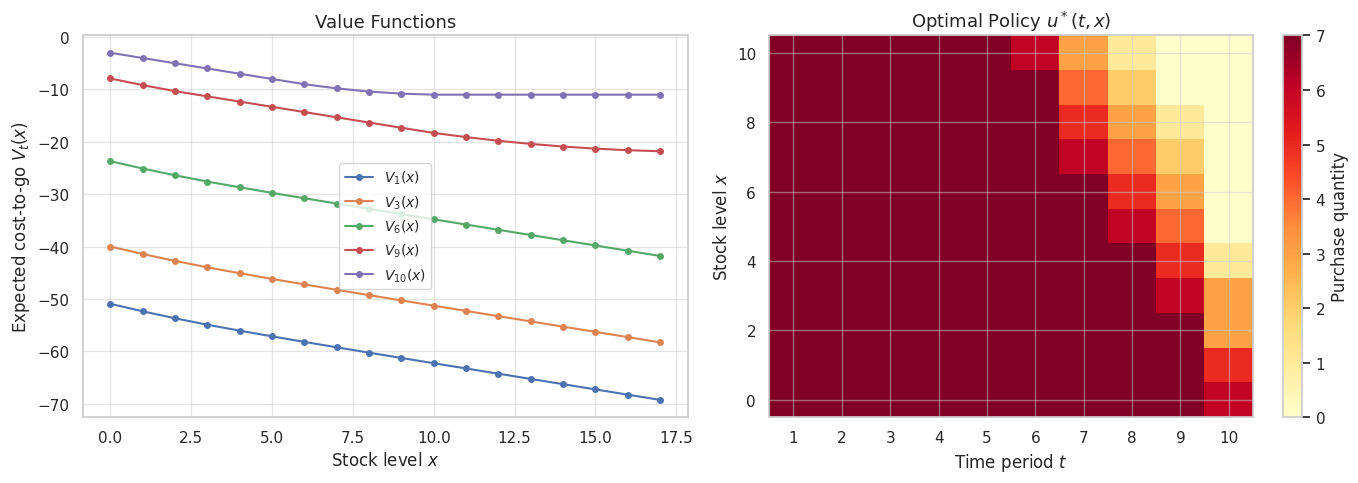

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Value functions at different time steps
ax = axes[0]
x_range = np.arange(D + U + 1)
for t in [0, 2, 5, 8, 9]:
    ax.plot(x_range, V[t], 'o-', markersize=4, label=f'$V_{{{t+1}}}(x)$')
ax.set_xlabel('Stock level $x$', fontsize=12)
ax.set_ylabel('Expected cost-to-go $V_t(x)$', fontsize=12)
ax.set_title('Value Functions', fontsize=13)
ax.legend(fontsize=10)

# Policy heatmap
ax = axes[1]
im = ax.imshow(policy[:, :D+1].T, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_xlabel('Time period $t$', fontsize=12)
ax.set_ylabel('Stock level $x$', fontsize=12)
ax.set_title('Optimal Policy $u^*(t, x)$', fontsize=13)
ax.set_xticks(range(T))
ax.set_xticklabels(range(1, T+1))
plt.colorbar(im, ax=ax, label='Purchase quantity')

plt.tight_layout()
plt.show()

## 3. Policy Interpretation

The optimal policy exhibits a **base-stock** structure:
- Order up to a target level $S_t$ if stock is below $S_t$
- The target decreases near the end of the horizon (last day: don't overstock!)
- When $U$ is not binding, the policy is: $u^*(t, x) = \max(S_t - x, 0)$

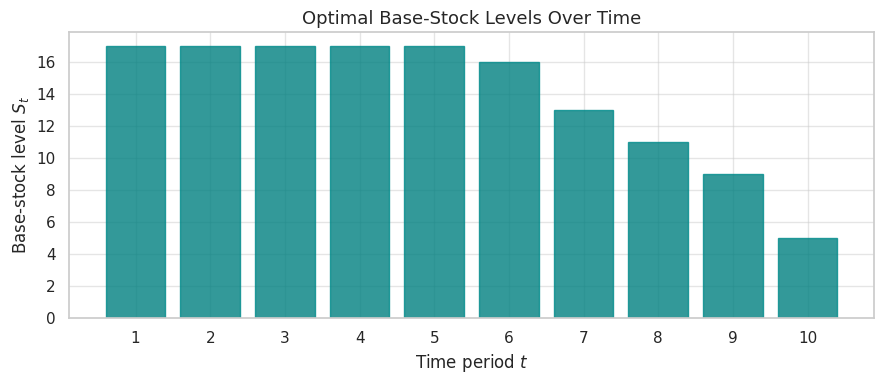

In [4]:
# Extract base-stock levels
base_stock = []
for t in range(T):
    for x in range(D + U + 1):
        if policy[t, x] == 0:
            base_stock.append(x)
            break
    else:
        base_stock.append(D + U)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, T+1), base_stock, color='teal', alpha=0.8, edgecolor='darkcyan')
ax.set_xlabel('Time period $t$', fontsize=12)
ax.set_ylabel('Base-stock level $S_t$', fontsize=12)
ax.set_title('Optimal Base-Stock Levels Over Time', fontsize=13)
ax.set_xticks(range(1, T+1))
plt.tight_layout()
plt.show()

## 4. Validation by Monte Carlo Simulation

In [5]:
# Generate scenarios for validation
n_mc = 5000
scenarios = generate_scenarios(n_mc, T, D, seed=42)

# Simulate DP optimal policy
dp_pol = dp_policy_function(policy)
dp_cost, dp_ci = simulate_policy(scenarios, dp_pol, c, p, U)

# Compare with bounds and heuristics
ant_mean, ant_ci = anticipative_bound(scenarios[:200], c, p, U)
const5_cost, const5_ci = simulate_policy(scenarios, constant_policy(5.0), c, p, U)

print(f"{'Method':<35} {'Cost':<12} {'95% CI'}")
print('=' * 60)
print(f"{'Anticipative LB (perfect info)':<35} {ant_mean:<12.2f} ±{ant_ci:.2f}")
print(f"{'DP Optimal Policy':<35} {dp_cost:<12.2f} ±{dp_ci:.2f}")
print(f"{'Constant u=5':<35} {const5_cost:<12.2f} ±{const5_ci:.2f}")
print(f"\nDP theoretical value V_0(0) = {V[0,0]:.2f}")
print(f"DP simulated value = {dp_cost:.2f} (difference: {abs(dp_cost - V[0,0]):.2f})")
print(f"\n→ The simulation confirms the DP solution!")

Method                              Cost         95% CI
Anticipative LB (perfect info)      -53.63       ±1.11
DP Optimal Policy                   -50.91       ±0.23
Constant u=5                        -42.56       ±0.23

DP theoretical value V_0(0) = -50.93
DP simulated value = -50.91 (difference: 0.03)

→ The simulation confirms the DP solution!


## 5. Sensitivity Analysis

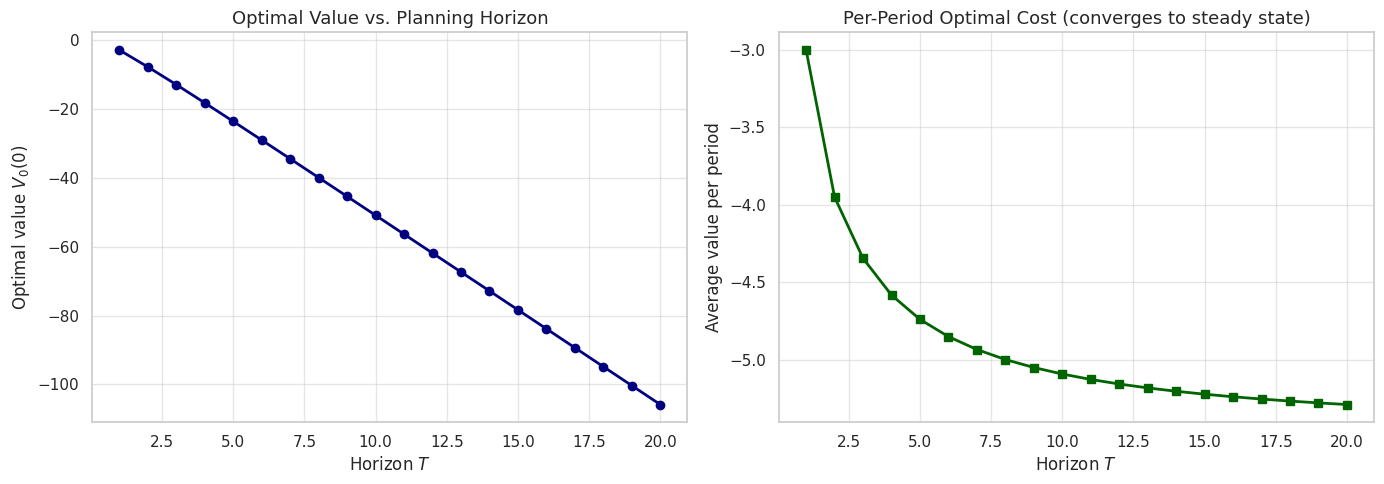

Steady-state per-period cost ≈ -5.290


In [6]:
# How does the optimal value change with T?
T_range = range(1, 21)
dp_values = []
for t_val in T_range:
    V_t, _ = solve_dp(t_val, D, c, p, U)
    dp_values.append(V_t[0, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(T_range), dp_values, 'o-', color='navy', linewidth=2, markersize=6)
ax.set_xlabel('Horizon $T$', fontsize=12)
ax.set_ylabel('Optimal value $V_0(0)$', fontsize=12)
ax.set_title('Optimal Value vs. Planning Horizon', fontsize=13)

# Per-period value
ax = axes[1]
per_period = [v / t for v, t in zip(dp_values, T_range)]
ax.plot(list(T_range), per_period, 's-', color='darkgreen', linewidth=2, markersize=6)
ax.set_xlabel('Horizon $T$', fontsize=12)
ax.set_ylabel('Average value per period', fontsize=12)
ax.set_title('Per-Period Optimal Cost (converges to steady state)', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Steady-state per-period cost ≈ {per_period[-1]:.3f}")

## Summary

| Aspect | Detail |
|--------|--------|
| Algorithm | Backward induction (Bellman recursion) |
| Complexity | $O(T \cdot |X| \cdot |U| \cdot D)$ = polynomial |
| Policy structure | Base-stock (order up to $S_t$) |
| End-of-horizon effect | Target stock decreases near $T$ |

### Notes
- DP gives the **exact** optimal solution when the state space is manageable
- The curse of dimensionality limits DP to problems with few state variables
- The optimal policy has an interpretable base-stock structure
- DP is vastly more efficient than the extensive formulation ($O(D^T)$)